# Member 3 — SVM & GRU (Resume Classification)

## 2.1 Source and Size
**Source:** Kaggle — Resume Dataset (`gauravduttakiit/resumedataset`)
https://www.kaggle.com/datasets/gauravduttakiit/resumedataset

**Raw size:** 962 rows, 2 columns (`Category`, `Resume`), 25 categories.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/Priyanshu-1729/Resume-Screening-using-Python/main/UpdatedResumeDataSet.csv"
df_raw = pd.read_csv(url)

print("Raw rows:            ", len(df_raw))
print("Unique resume texts: ", df_raw['Resume'].nunique())
print("Duplicate rate:       {:.1%}".format(1 - df_raw['Resume'].nunique()/len(df_raw)))
print("Categories:          ", df_raw['Category'].nunique())

Raw rows:             962
Unique resume texts:  166
Duplicate rate:       82.7%
Categories:           25


### Deduplication
Drop exact duplicate resume texts. This is the fix for the train/test leakage described above.

In [2]:
df = df_raw.drop_duplicates(subset=['Resume']).reset_index(drop=True)
print("After dedup:", df.shape)
print(df['Category'].value_counts())

After dedup: (166, 2)
Category
Java Developer               13
Database                     11
Advocate                     10
HR                           10
Data Science                 10
Automation Testing            7
DevOps Engineer               7
Testing                       7
DotNet Developer              7
Hadoop                        7
SAP Developer                 6
Python Developer              6
Health and fitness            6
Civil Engineer                6
Arts                          6
Business Analyst              6
Sales                         5
Blockchain                    5
Mechanical Engineer           5
ETL Developer                 5
Electrical Engineering        5
Network Security Engineer     5
Web Designing                 4
Operations Manager            4
PMO                           3
Name: count, dtype: int64


## Preprocessing

In [3]:
import re
import nltk
nltk.download('punkt'); nltk.download('punkt_tab')
nltk.download('stopwords'); nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_resume(text):
    text = re.sub(r'http\S+\s*', ' ', text)
    text = re.sub(r'#\S+', '', text)
    text = re.sub(r'@\S+', '  ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.lower().strip()

def preprocess(text):
    tokens = word_tokenize(clean_resume(text))
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

df['cleaned_resume'] = df['Resume'].apply(preprocess)
df[['Category','cleaned_resume']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,Category,cleaned_resume
0,Data Science,skill programming language python panda numpy ...
1,Data Science,education detail may may uit rgpv data scienti...
2,Data Science,area interest deep learning control system des...
3,Data Science,skill python sap hana tableau sap hana sql sap...
4,Data Science,education detail mca ymcaust faridabad haryana...


## Model 1 — SVM (TF-IDF features)

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])
y = df['Category_encoded']

tfidf = TfidfVectorizer(max_features=3000, sublinear_tf=True, stop_words='english')
X_tfidf = tfidf.fit_transform(df['cleaned_resume'])

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape, " Classes:", len(le.classes_))

Train: (132, 3000)  Test: (34, 3000)  Classes: 25


In [5]:
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report)

svm = SVC(kernel='linear', class_weight='balanced', probability=True)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

svm_acc  = accuracy_score(y_test, y_pred)
svm_prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
svm_rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
svm_f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"Accuracy:          {svm_acc:.4f}")
print(f"Precision (macro): {svm_prec:.4f}")
print(f"Recall (macro):    {svm_rec:.4f}")
print(f"F1-Score (macro):  {svm_f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

Accuracy:          0.7353
Precision (macro): 0.5973
Recall (macro):    0.7000
F1-Score (macro):  0.6233

                           precision    recall  f1-score   support

                 Advocate       1.00      0.50      0.67         2
                     Arts       1.00      1.00      1.00         1
       Automation Testing       0.50      1.00      0.67         1
               Blockchain       1.00      1.00      1.00         1
         Business Analyst       0.50      1.00      0.67         1
           Civil Engineer       1.00      1.00      1.00         1
             Data Science       1.00      1.00      1.00         2
                 Database       1.00      1.00      1.00         2
          DevOps Engineer       0.33      1.00      0.50         1
         DotNet Developer       1.00      1.00      1.00         2
            ETL Developer       1.00      1.00      1.00         1
   Electrical Engineering       1.00      1.00      1.00         1
                       

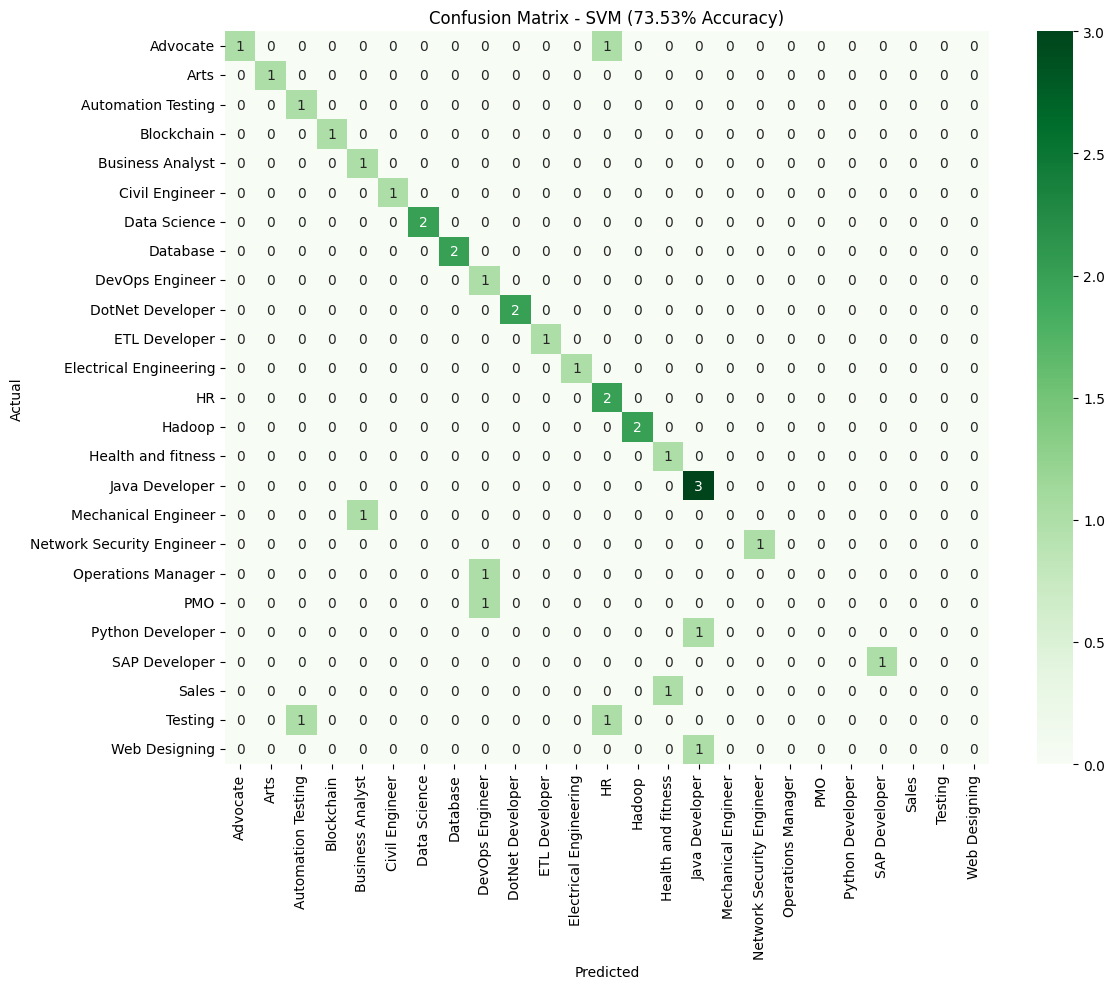

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix - SVM ({svm_acc*100:.2f}% Accuracy)')   # title reads from the real result
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig('confusion_matrix_svm.png', dpi=300); plt.show()

### Optional: leakage check
Re-run the same SVM on the **original 962 rows** to show how much the duplicates inflate the
score. Report both numbers in the write-up — the gap is the finding.

In [7]:
df_leak = df_raw.copy()
df_leak['cleaned_resume'] = df_leak['Resume'].apply(preprocess)
y_leak = LabelEncoder().fit_transform(df_leak['Category'])
X_leak = TfidfVectorizer(max_features=3000, sublinear_tf=True,
                         stop_words='english').fit_transform(df_leak['cleaned_resume'])

Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(
    X_leak, y_leak, test_size=0.2, random_state=42, stratify=y_leak)

svm_leak = SVC(kernel='linear', class_weight='balanced').fit(Xl_tr, yl_tr)
print(f"SVM accuracy WITH duplicates:    {accuracy_score(yl_te, svm_leak.predict(Xl_te)):.4f}")
print(f"SVM accuracy WITHOUT duplicates: {svm_acc:.4f}")

SVM accuracy WITH duplicates:    0.9948
SVM accuracy WITHOUT duplicates: 0.7353


## Model 2 — GRU

In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 5000
MAX_LEN   = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_resume'])
X_padded = pad_sequences(tokenizer.texts_to_sequences(df['cleaned_resume']),
                         maxlen=MAX_LEN, padding='post', truncating='post')

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_padded, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train_dl.shape, " Test:", X_test_dl.shape)

Train: (132, 200)  Test: (34, 200)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

num_classes = len(le.classes_)
y_train_cat = to_categorical(y_train_dl, num_classes=num_classes)
y_test_cat  = to_categorical(y_test_dl,  num_classes=num_classes)

model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    GRU(64),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# NOTE: monitor val_loss, not val_accuracy. With ~34 test samples, val_accuracy moves in
# 3% jumps and restore_best_weights will happily pick a lucky epoch.
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train_dl, y_train_cat,
                    validation_data=(X_test_dl, y_test_cat),
                    epochs=30, batch_size=16, callbacks=[early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.0455 - loss: 3.2211 - val_accuracy: 0.1471 - val_loss: 3.2074
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.1515 - loss: 3.2022 - val_accuracy: 0.1471 - val_loss: 3.1969
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - accuracy: 0.1667 - loss: 3.1826 - val_accuracy: 0.1471 - val_loss: 3.1842
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.0985 - loss: 3.1699 - val_accuracy: 0.1176 - val_loss: 3.1715
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.1439 - loss: 3.1443 - val_accuracy: 0.1176 - val_loss: 3.1533
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.1591 - loss: 3.1086 - val_accuracy: 0.1471 - val_loss: 3.1324
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.1212 - loss: 3.0859 - val_accuracy: 0.1176 - val_loss: 3.1071
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.1439 - loss: 3.0265 - val_accuracy: 0.1176 - val_loss:

In [10]:
import numpy as np

y_pred_gru = np.argmax(model.predict(X_test_dl), axis=1)

gru_acc  = accuracy_score(y_test_dl, y_pred_gru)
gru_prec = precision_score(y_test_dl, y_pred_gru, average='macro', zero_division=0)
gru_rec  = recall_score(y_test_dl, y_pred_gru, average='macro', zero_division=0)
gru_f1   = f1_score(y_test_dl, y_pred_gru, average='macro', zero_division=0)

print(f"Accuracy:          {gru_acc:.4f}")
print(f"Precision (macro): {gru_prec:.4f}")
print(f"Recall (macro):    {gru_rec:.4f}")
print(f"F1-Score (macro):  {gru_f1:.4f}")
print()
print(classification_report(y_test_dl, y_pred_gru, target_names=le.classes_, zero_division=0))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 268ms/step
Accuracy:          0.1176
Precision (macro): 0.0235
Recall (macro):    0.0667
F1-Score (macro):  0.0325

                           precision    recall  f1-score   support

                 Advocate       0.00      0.00      0.00         2
                     Arts       0.00      0.00      0.00         1
       Automation Testing       0.00      0.00      0.00         1
               Blockchain       0.00      0.00      0.00         1
         Business Analyst       0.00      0.00      0.00         1
           Civil Engineer       0.00      0.00      0.00         1
             Data Science       0.00      0.00      0.00         2
                 Database       0.14      0.50      0.22         2
          DevOps Engineer       0.00      0.00      0.00         1
         DotNet Developer       0.00      0.00      0.00         2
            ETL Developer       0.00      0.00      0.00         1
   Electrical Engineering       0.00      0.00     

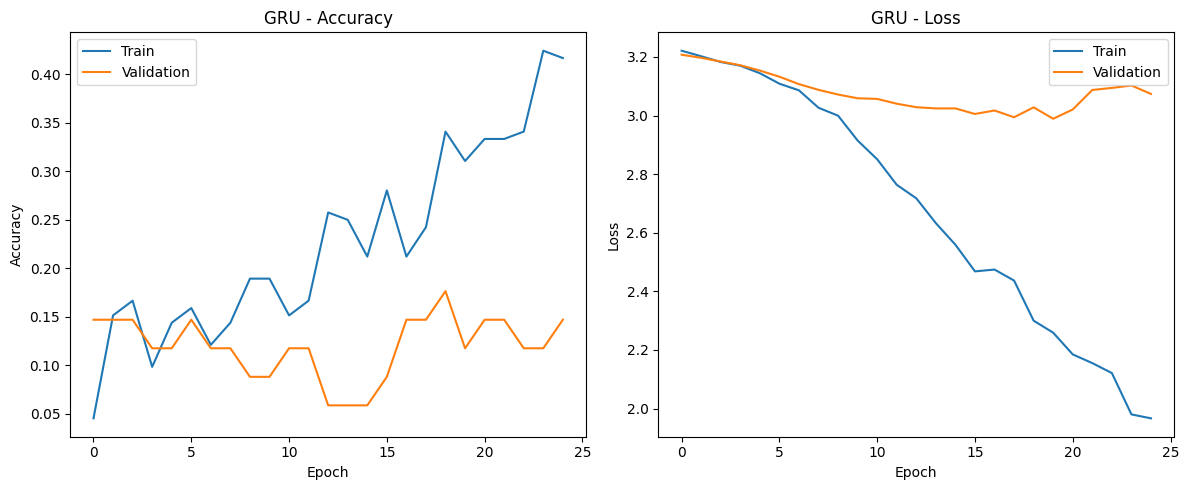

In [11]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('GRU - Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('GRU - Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout(); plt.savefig('gru_training_curves.png', dpi=150); plt.show()

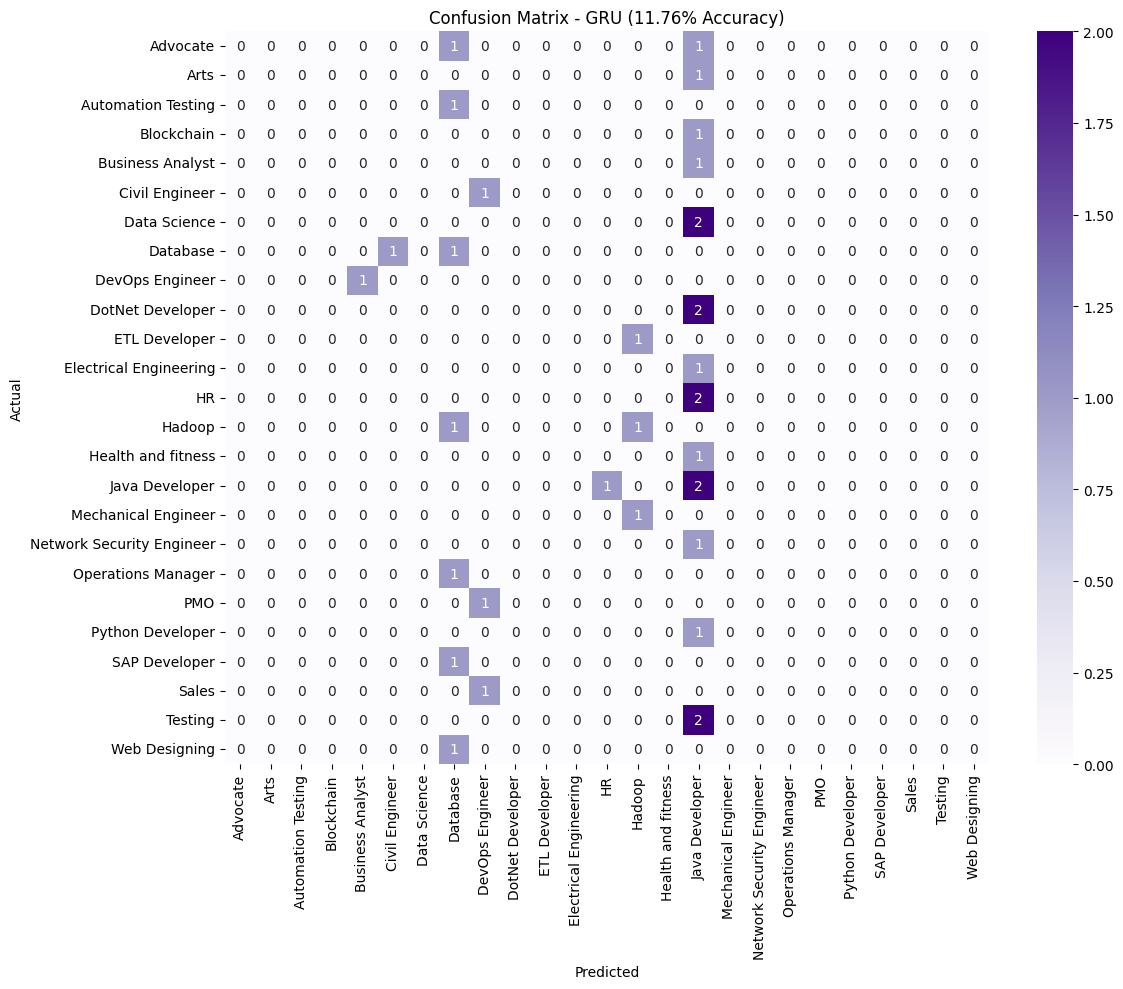

In [12]:
cm = confusion_matrix(y_test_dl, y_pred_gru)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix - GRU ({gru_acc*100:.2f}% Accuracy)')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig('confusion_matrix_gru.png', dpi=150); plt.show()

## Export results

In [13]:
results = pd.DataFrame([
    {"Model": "SVM", "Accuracy": svm_acc, "Precision (macro)": svm_prec,
     "Recall (macro)": svm_rec, "F1-Score (macro)": svm_f1},
    {"Model": "GRU", "Accuracy": gru_acc, "Precision (macro)": gru_prec,
     "Recall (macro)": gru_rec, "F1-Score (macro)": gru_f1},
])
results.to_csv('member3_results.csv', index=False)
print(results.to_string(index=False))

Model  Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
  SVM  0.735294           0.597333        0.700000          0.623333
  GRU  0.117647           0.023492        0.066667          0.032508


In [14]:
import joblib
joblib.dump(svm, 'svm_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer_svm.pkl')
joblib.dump(le, 'svm_label_encoder.pkl')
model.save('gru_model.h5')
joblib.dump(tokenizer, 'gru_tokenizer.pkl')

from google.colab import files
for f in ['member3_results.csv','confusion_matrix_svm.png','confusion_matrix_gru.png',
          'gru_training_curves.png','svm_model.pkl','tfidf_vectorizer_svm.pkl',
          'svm_label_encoder.pkl','gru_model.h5','gru_tokenizer.pkl']:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>